# Retail Customer Segmentation & KPI Analytics
## A Python Workflow for CRM Decision-Making
**Course:** IS513E – Database for Direct Marketing & E-CRM  
**Dataset:** Retail Transactional Dataset (Kaggle – bhavikjikadara)  
**Group:** Yasmine CHAKER · Mohamed HADJI · Hiba RHARS · Niranjan SAWANT  
**Date:** February 2026

---
> **Run order:** Execute all cells top-to-bottom. Each section is self-contained.
>
> **Dataset:** Upload `retail_transactional_dataset.csv` to your Colab session
> (or mount Google Drive) before running Phase 1.

## 0 · Environment Setup
Install / upgrade required libraries (Colab-safe).

In [1]:
import subprocess, sys
pkgs = ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "plotly", "kaleido"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade"] + pkgs)
print("All packages ready.")


All packages ready.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({
    "figure.facecolor": "#f9f9f9",
    "axes.facecolor":   "#f9f9f9",
    "axes.edgecolor":   "#cccccc",
    "grid.color":       "#e0e0e0",
})
PALETTE = sns.color_palette("Set2", 10)
print("Libraries imported OK.")


Libraries imported OK.


---
## Phase 1 · Data Import & Cleaning
**Owner:** Niranjan SAWANT

Steps: load CSV · inspect structure · handle nulls · remove duplicates · fix dtypes.

In [3]:
# 1.1  Load CSV
# Uncomment the two lines below to upload interactively in Colab:
# from google.colab import files
# uploaded = files.upload()   # then set FILE to the key name

FILE = "retail_transactional_dataset.csv"   # adjust path if needed

df_raw = pd.read_csv(FILE)
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head(3)


Shape: 2,000 rows x 12 columns


,Transaction ID,Customer ID,Date,Product Category,Quantity,Price Per Unit,Payment Method,Store Location,Discount Applied,Age,Gender,Total Amount
0,T101902,C1153,2025-01-01 11:00:00,Electronics,4,76.63,Credit Card,Strasbourg,No,43,Female,306.52
1,T101091,C1097,2025-01-01 14:00:00,Electronics,5,421.51,Debit Card,Montpellier,No,19,Male,2107.55
2,T100267,C1267,2025-01-01 21:00:00,Home Decor,9,23.99,Cash,Toulouse,Yes,31,Male,215.91


In [4]:
# 1.2  Structural inspection
print("DATA TYPES")
print(df_raw.dtypes)
print()
miss     = df_raw.isnull().sum()
miss_pct = (miss / len(df_raw) * 100).round(2)
missing  = pd.DataFrame({"Missing": miss, "Pct%": miss_pct})
print("MISSING VALUES")
print(missing[missing["Missing"] > 0])


DATA TYPES
Transaction ID       object
Customer ID          object
Date                 object
Product Category     object
Quantity              int64
Price Per Unit      float64
Payment Method       object
Store Location       object
Discount Applied     object
Age                   int64
Gender               object
Total Amount        float64
dtype: object

MISSING VALUES
Empty DataFrame
Columns: [Missing, Pct%]
Index: []


In [5]:
# 1.3  Normalise column names  (lower-snake-case)
df_raw.columns = (
    df_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[\s/]+", "_", regex=True)
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)
print("Columns:", df_raw.columns.tolist())


Columns: ['transaction_id', 'customer_id', 'date', 'product_category', 'quantity', 'price_per_unit', 'payment_method', 'store_location', 'discount_applied', 'age', 'gender', 'total_amount']


In [6]:
# 1.4  Auto-detect column mapping
HINTS = {
    "transaction_id": "transaction",
    "customer_id":    "customer",
    "date":           "date",
    "category":       "category",
    "quantity":       "quantity",
    "price":          "price",
    "total":          "total",
    "payment":        "payment",
    "location":       "location",
    "discount":       "discount",
    "age":            "age",
    "gender":         "gender",
}
actual = {}
for key, hint in HINTS.items():
    found = [c for c in df_raw.columns if hint in c]
    actual[key] = found[0] if found else None

print("Column mapping:")
for k, v in actual.items():
    print(f"  {k:20s} -> {v}")


Column mapping:
  transaction_id       -> transaction_id
  customer_id          -> customer_id
  date                 -> date
  category             -> product_category
  quantity             -> quantity
  price                -> price_per_unit
  total                -> total_amount
  payment              -> payment_method
  location             -> store_location
  discount             -> discount_applied
  age                  -> age
  gender               -> gender


In [7]:
# 1.5  Build clean working dataframe
needed = {k: v for k, v in actual.items() if v is not None}
df = df_raw[[v for v in needed.values()]].copy()
df.columns = list(needed.keys())

# Parse dates
df["date"] = pd.to_datetime(df["date"], infer_datetime_format=True, errors="coerce")

# Numeric coercion
for col in ["quantity", "price", "total"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing core fields
core = [c for c in ["transaction_id", "customer_id", "date", "total"] if c in df.columns]
before = len(df)
df.dropna(subset=core, inplace=True)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Records after cleaning: {after:,}  (removed {before - after:,})")
df.head(3)


Records after cleaning: 2,000  (removed 0)


,transaction_id,customer_id,date,category,quantity,price,total,payment,location,discount,age,gender
0,T101902,C1153,2025-01-01 11:00:00,Electronics,4,76.63,306.52,Credit Card,Strasbourg,No,43,Female
1,T101091,C1097,2025-01-01 14:00:00,Electronics,5,421.51,2107.55,Debit Card,Montpellier,No,19,Male
2,T100267,C1267,2025-01-01 21:00:00,Home Decor,9,23.99,215.91,Cash,Toulouse,Yes,31,Male


In [8]:
# 1.6  Compute total if missing
if "total" not in df.columns and "quantity" in df.columns and "price" in df.columns:
    df["total"] = df["quantity"] * df["price"]
    print("total computed from quantity x price.")

# Remove negative totals
df = df[df["total"] >= 0]
print(f"Final clean shape: {df.shape}")


Final clean shape: (2000, 12)


---
## Phase 2 · Data Diagnosis & GDPR Review
**Owner:** Niranjan SAWANT

Assess data quality and flag GDPR-sensitive fields (Reg. EU 2016/679).

In [9]:
# 2.1  Overall data quality report
print("OVERALL DATA QUALITY REPORT")
print(f"  Total records       : {len(df):,}")
print(f"  Unique customers    : {df['customer_id'].nunique():,}")
print(f"  Unique transactions : {df['transaction_id'].nunique():,}")
print(f"  Date range          : {df['date'].min().date()} to {df['date'].max().date()}")
print()
print("DESCRIPTIVE STATISTICS")
num_cols = df.select_dtypes(include="number").columns.tolist()
display(df[num_cols].describe().round(2))


OVERALL DATA QUALITY REPORT
  Total records       : 2,000
  Unique customers    : 489
  Unique transactions : 2,000
  Date range          : 2025-01-01 to 2025-12-31

DESCRIPTIVE STATISTICS


,quantity,price,total,age
count,2000.00,2000.00,2000.00,2000.00
mean,4.99,245.49,1234.19,45.96
std,2.61,140.18,1034.06,16.38
min,1.00,5.03,5.64,18.00
25%,3.00,127.64,400.82,32.00
50%,5.00,242.80,937.88,46.00
75%,7.00,359.83,1805.42,60.00
max,9.00,499.46,4480.38,74.00


In [10]:
# 2.2  GDPR field risk assessment
GDPR_MAP = {
    "customer_id": ("Pseudonymous ID",   "LOW  - opaque token, no direct identity"),
    "age":         ("Quasi-identifier",  "MED  - combined with gender/city raises re-ID risk"),
    "gender":      ("Quasi-identifier",  "MED  - as above"),
    "location":    ("Quasi-identifier",  "MED  - city-level geographic data"),
}

SEP = "=" * 70
print(SEP)
print("  GDPR FIELD RISK ASSESSMENT")
print(SEP)
print(f"  {'Field':<16}  {'Classification':<22}  Risk Note")
print("-" * 70)
for field, (cls, risk) in GDPR_MAP.items():
    if field in df.columns:
        print(f"  {field:<16}  {cls:<22}  {risk}")
print(SEP)

mitigations = [
    "Customer IDs treated as opaque tokens - never decoded.",
    "Age kept as numeric range; no real names or DOBs present.",
    "City/location used for aggregate visualisation only.",
    "No join to external datasets that could enable re-identification.",
    "Data minimisation: only fields required for analysis are retained.",
    "Legal basis: academic research under Art. 89 GDPR.",
]
print("\nGDPR Mitigations applied:")
for m in mitigations:
    print(f"  [OK] {m}")


  GDPR FIELD RISK ASSESSMENT
  Field             Classification          Risk Note
----------------------------------------------------------------------
  customer_id       Pseudonymous ID         LOW  - opaque token, no direct identity
  age               Quasi-identifier        MED  - combined with gender/city raises re-ID risk
  gender            Quasi-identifier        MED  - as above
  location          Quasi-identifier        MED  - city-level geographic data

GDPR Mitigations applied:
  [OK] Customer IDs treated as opaque tokens - never decoded.
  [OK] Age kept as numeric range; no real names or DOBs present.
  [OK] City/location used for aggregate visualisation only.
  [OK] No join to external datasets that could enable re-identification.
  [OK] Data minimisation: only fields required for analysis are retained.
  [OK] Legal basis: academic research under Art. 89 GDPR.


In [11]:
# 2.3  Age band anonymisation
if "age" in df.columns:
    bins   = [0, 25, 35, 45, 55, 65, 120]
    labels = ["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
    df["age_band"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)
    print("Age bands:", df["age_band"].value_counts().sort_index().to_dict())


Age bands: {'<25': 237, '25-34': 364, '35-44': 354, '45-54': 328, '55-64': 367, '65+': 350}


---
## Phase 3 · Exploratory Data Analysis (EDA)
**Owner:** Yasmine CHAKER

Visualise spending patterns, top customers, and seasonal trends.

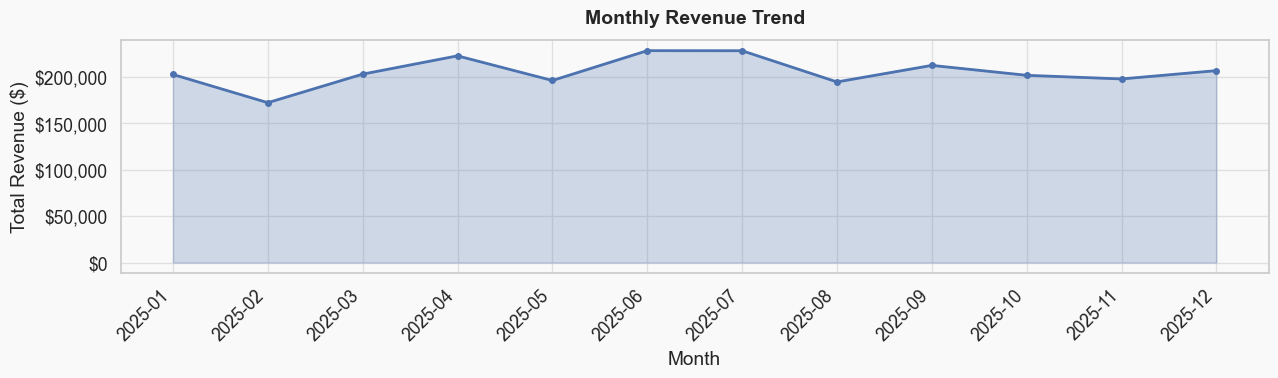

In [12]:
# 3.1  Monthly revenue trend
df["year_month"] = df["date"].dt.to_period("M")
monthly = df.groupby("year_month")["total"].sum().reset_index()
monthly["year_month"] = monthly["year_month"].astype(str)

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(monthly["year_month"], monthly["total"], alpha=0.25, color="#4C72B0")
ax.plot(monthly["year_month"], monthly["total"],
        marker="o", markersize=4, color="#4C72B0", linewidth=2)
ax.set_title("Monthly Revenue Trend", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
step = max(1, len(monthly) // 10)
tick_pos = list(range(0, len(monthly), step))
ax.set_xticks(tick_pos)
ax.set_xticklabels([monthly["year_month"].iloc[i] for i in tick_pos], rotation=45, ha="right")
plt.tight_layout()
plt.show()


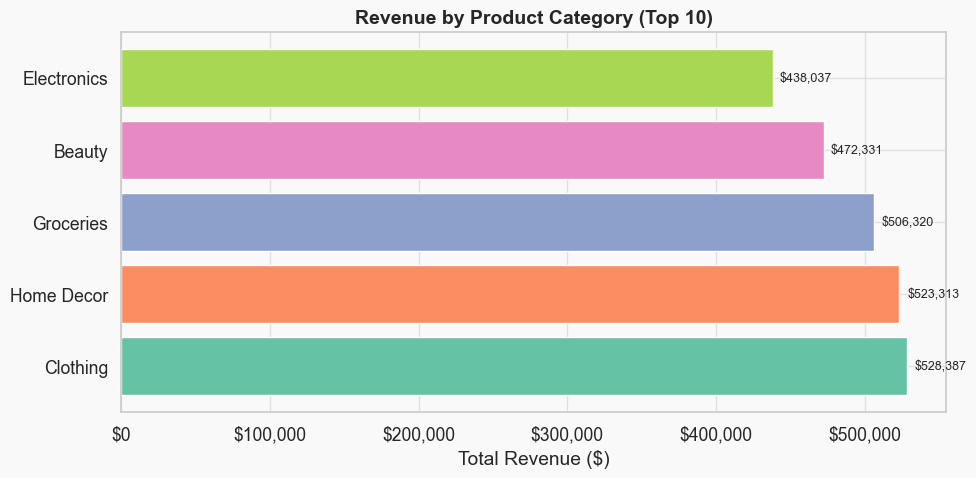

In [13]:
# 3.2  Revenue by product category
if "category" in df.columns:
    cat_rev = df.groupby("category")["total"].sum().sort_values(ascending=False).head(10)
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(cat_rev.index, cat_rev.values, color=PALETTE[:len(cat_rev)])
    ax.set_title("Revenue by Product Category (Top 10)", fontsize=14, fontweight="bold")
    ax.set_xlabel("Total Revenue ($)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    for bar in bars:
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                f"${bar.get_width():,.0f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()


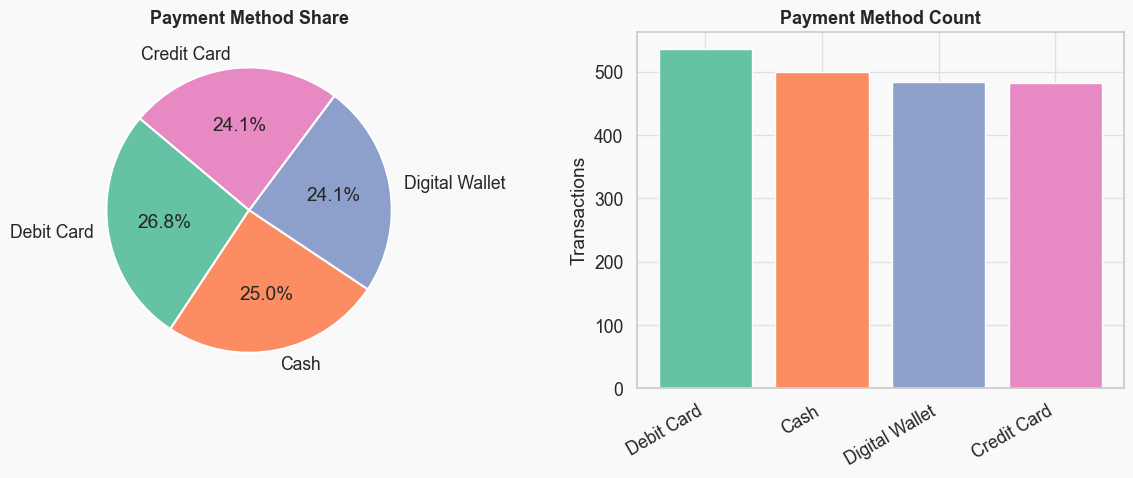

In [14]:
# 3.3  Payment method split
if "payment" in df.columns:
    pay_counts = df["payment"].value_counts()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.pie(pay_counts, labels=pay_counts.index, autopct="%1.1f%%",
            colors=PALETTE[:len(pay_counts)], startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
    ax1.set_title("Payment Method Share", fontsize=13, fontweight="bold")
    ax2.bar(pay_counts.index, pay_counts.values,
            color=PALETTE[:len(pay_counts)], edgecolor="white")
    ax2.set_title("Payment Method Count", fontsize=13, fontweight="bold")
    ax2.set_ylabel("Transactions")
    plt.setp(ax2.get_xticklabels(), rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


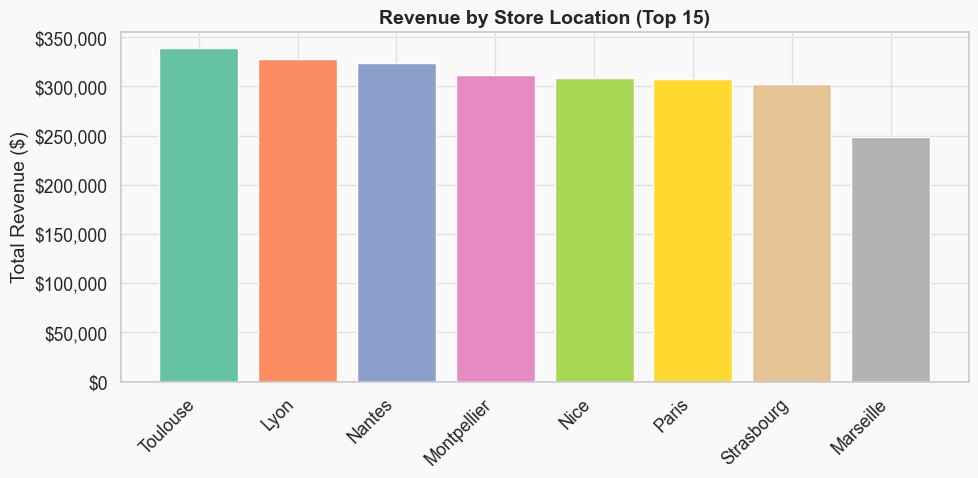

In [15]:
# 3.4  Revenue by store location (top 15)
if "location" in df.columns:
    city_rev = df.groupby("location")["total"].sum().sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(city_rev.index, city_rev.values, color=PALETTE[:len(city_rev)], edgecolor="white")
    ax.set_title("Revenue by Store Location (Top 15)", fontsize=14, fontweight="bold")
    ax.set_ylabel("Total Revenue ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


Discount Applied  Avg Order Value  Transactions
      Full Price      1234.611170          1376
      Discounted      1233.274071           624


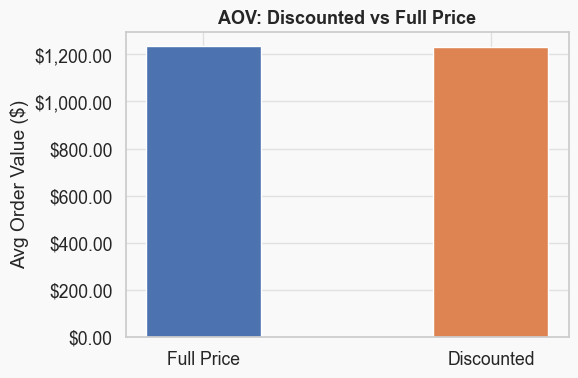

In [16]:
# 3.5  Discount impact on AOV
if "discount" in df.columns:
    df["discount_flag"] = df["discount"].astype(str).str.upper().isin(["YES", "TRUE", "1", "Y"])
    disc = df.groupby("discount_flag")["total"].agg(["mean", "count"]).reset_index()
    disc.columns = ["Discount Applied", "Avg Order Value", "Transactions"]
    disc["Discount Applied"] = disc["Discount Applied"].map({True: "Discounted", False: "Full Price"})
    print(disc.to_string(index=False))

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(disc["Discount Applied"], disc["Avg Order Value"],
           color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.4)
    ax.set_title("AOV: Discounted vs Full Price", fontsize=13, fontweight="bold")
    ax.set_ylabel("Avg Order Value ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.2f}"))
    plt.tight_layout()
    plt.show()


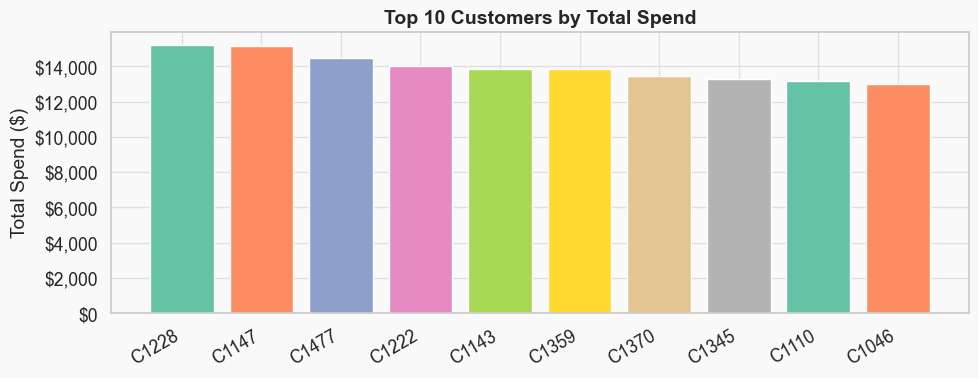

In [17]:
# 3.6  Top 10 customers by spend
top10 = (df.groupby("customer_id")["total"]
           .sum().sort_values(ascending=False).head(10).reset_index())
top10.columns = ["Customer ID", "Total Spend"]
top10["Customer ID"] = top10["Customer ID"].astype(str).str[-6:]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(top10["Customer ID"], top10["Total Spend"],
              color=PALETTE[:10], edgecolor="white")
ax.set_title("Top 10 Customers by Total Spend", fontsize=14, fontweight="bold")
ax.set_ylabel("Total Spend ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


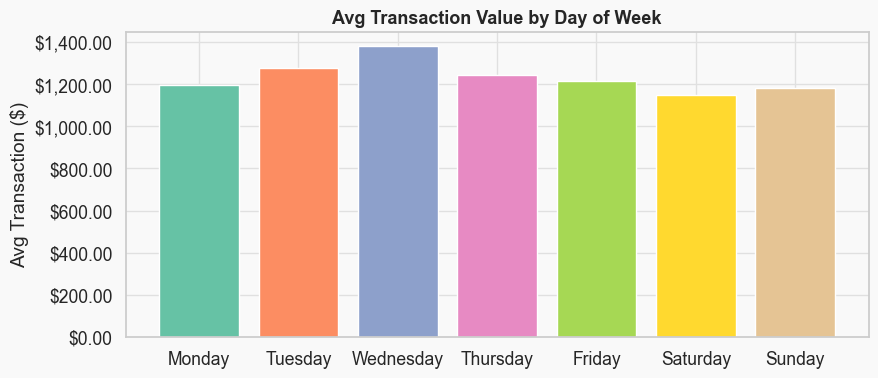

In [18]:
# 3.7  Average spend by day of week
df["day_of_week"] = df["date"].dt.day_name()
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_rev = df.groupby("day_of_week")["total"].mean().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(dow_rev.index, dow_rev.values, color=PALETTE[:7], edgecolor="white")
ax.set_title("Avg Transaction Value by Day of Week", fontsize=13, fontweight="bold")
ax.set_ylabel("Avg Transaction ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.2f}"))
plt.tight_layout()
plt.show()


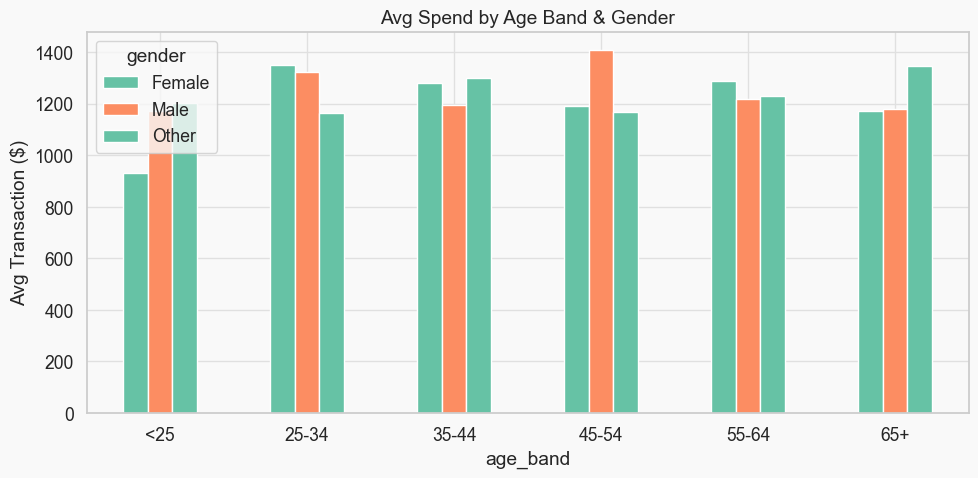

In [19]:
# 3.8  Demographics heatmap (age band x gender)
demo_cols = [c for c in ["age_band", "gender"] if c in df.columns]
if len(demo_cols) == 2:
    piv = df.groupby(["age_band", "gender"])["total"].mean().unstack()
    piv.plot(kind="bar", figsize=(10, 5), color=PALETTE[:2], edgecolor="white",
             title="Avg Spend by Age Band & Gender")
    plt.ylabel("Avg Transaction ($)")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
elif "age_band" in df.columns:
    age_rev = df.groupby("age_band")["total"].mean()
    age_rev.plot(kind="bar", color=PALETTE, edgecolor="white",
                 title="Avg Spend by Age Band", figsize=(8, 4))
    plt.ylabel("Avg ($)")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


---
## Phase 4 · RFM Analysis & K-Means Customer Segmentation
**Owner:** Mohamed HADJI

### 4A – RFM Scoring
| Dimension | Definition |
|-----------|-----------|
| **Recency (R)** | Days since the customer's last purchase |
| **Frequency (F)** | Number of distinct transactions |
| **Monetary (M)** | Total spend over the observation period |

### 4B – K-Means Clustering
K-Means is applied on standardised RFM features to uncover data-driven segments.

In [20]:
# 4.1  Build RFM table
SNAPSHOT = df["date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("customer_id").agg(
    Recency   = ("date",           lambda x: (SNAPSHOT - x.max()).days),
    Frequency = ("transaction_id", "nunique"),
    Monetary  = ("total",          "sum")
).reset_index()

print(f"RFM table: {len(rfm):,} customers")
display(rfm.describe().round(2))


RFM table: 489 customers


,Recency,Frequency,Monetary
count,489.00,489.00,489.00
mean,86.82,4.09,5047.83
std,76.48,2.10,3291.43
min,1.00,1.00,34.14
25%,26.00,2.00,2503.34
50%,65.00,4.00,4442.18
75%,128.00,6.00,7118.63
max,362.00,10.00,15195.04


In [21]:
# 4.2  RFM quintile scores (1 = worst, 5 = best per dimension)
rfm["R_score"] = pd.qcut(rfm["Recency"],
                          5, labels=[5, 4, 3, 2, 1])   # lower recency = recent = better
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"),
                          5, labels=[1, 2, 3, 4, 5])
rfm["M_score"] = pd.qcut(rfm["Monetary"].rank(method="first"),
                          5, labels=[1, 2, 3, 4, 5])

rfm["RFM_score"]   = rfm[["R_score","F_score","M_score"]].astype(int).sum(axis=1)
rfm["RFM_segment"] = (rfm["R_score"].astype(str)
                     + rfm["F_score"].astype(str)
                     + rfm["M_score"].astype(str))
print("RFM Score summary:")
print(rfm["RFM_score"].describe().round(2))
rfm.head()


RFM Score summary:
count    489.00
mean       9.01
std        3.46
min        3.00
25%        6.00
50%        9.00
75%       12.00
max       15.00
Name: RFM_score, dtype: float64


,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_segment
0,C1000,52,8,10298.64,3,5,5,13,355
1,C1001,20,4,2392.25,5,3,2,10,532
2,C1002,204,1,278.08,1,1,1,3,111
3,C1003,66,5,8219.83,3,4,5,12,345
4,C1004,15,7,4575.55,5,5,3,13,553


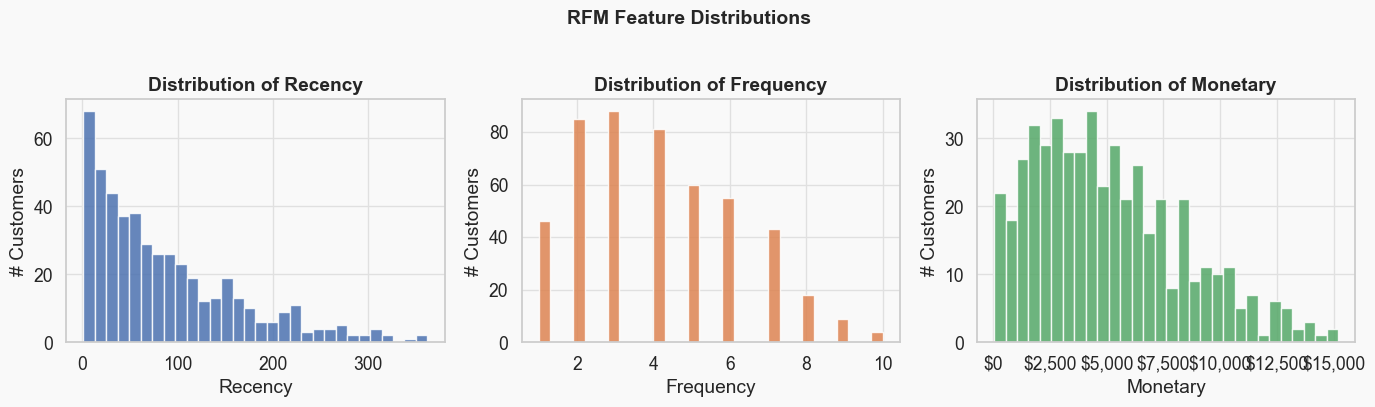

In [22]:
# 4.3  RFM distribution plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes,
                           ["Recency", "Frequency", "Monetary"],
                           ["#4C72B0", "#DD8452", "#55A868"]):
    ax.hist(rfm[col], bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"Distribution of {col}", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("# Customers")
    if col == "Monetary":
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.suptitle("RFM Feature Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


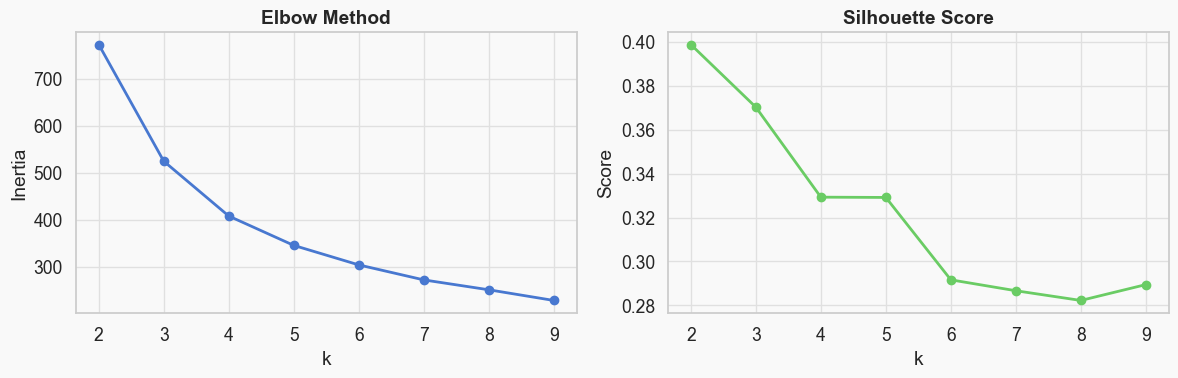

Best k by silhouette: 2  (score = 0.399)


In [23]:
# 4.4  Optimal k: Elbow + Silhouette
features = ["Recency", "Frequency", "Monetary"]
X_raw    = rfm[features].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

inertia_vals, sil_vals = [], []
K_range = range(2, 10)
for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertia_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(X_scaled, lbl))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_range), inertia_vals, "bo-", linewidth=2)
ax1.set_title("Elbow Method", fontweight="bold")
ax1.set_xlabel("k"); ax1.set_ylabel("Inertia")
ax2.plot(list(K_range), sil_vals, "go-", linewidth=2)
ax2.set_title("Silhouette Score", fontweight="bold")
ax2.set_xlabel("k"); ax2.set_ylabel("Score")
plt.tight_layout(); plt.show()

best_k = list(K_range)[sil_vals.index(max(sil_vals))]
print(f"Best k by silhouette: {best_k}  (score = {max(sil_vals):.3f})")


In [24]:
# 4.5  Final K-Means model
K = best_k   # change this to override, e.g. K = 4
km_final       = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm["Cluster"] = km_final.fit_predict(X_scaled)

profile = rfm.groupby("Cluster")[features].mean().round(2)
profile["Count"] = rfm.groupby("Cluster").size().values
profile["Pct%"]  = (profile["Count"] / len(rfm) * 100).round(1)
print("CLUSTER PROFILES")
display(profile.sort_values("Monetary", ascending=False))


CLUSTER PROFILES


,Recency,Frequency,Monetary,Count,Pct%
Cluster,,,,,
1,45.78,5.95,7876.40,215,44.0
0,119.03,2.63,2828.33,274,56.0


In [25]:
# 4.6  Assign business segment labels (ranked by Monetary value)
cluster_order = profile.sort_values("Monetary", ascending=False).index.tolist()
LABEL_POOL = [
    "Champions", "Loyal Customers", "At-Risk Customers",
    "Lost Customers", "New Customers", "Potential Loyalists",
    "Cannot-Lose", "Hibernating",
]
label_map = {cl: LABEL_POOL[i] if i < len(LABEL_POOL) else f"Segment {i+1}"
             for i, cl in enumerate(cluster_order)}

rfm["Segment"] = rfm["Cluster"].map(label_map)
print("Segment sizes:")
print(rfm["Segment"].value_counts().to_string())


Segment sizes:
Segment
Loyal Customers    274
Champions          215


In [26]:
# 4.7  Interactive 3-D RFM scatter (Plotly)
fig_3d = px.scatter_3d(
    rfm, x="Recency", y="Frequency", z="Monetary",
    color="Segment", symbol="Segment",
    title="Customer Segments in RFM Space",
    labels={"Recency":"Recency (days)", "Frequency":"# Transactions", "Monetary":"Spend ($)"},
    opacity=0.75, height=600,
)
fig_3d.update_traces(marker=dict(size=3))
fig_3d.show()


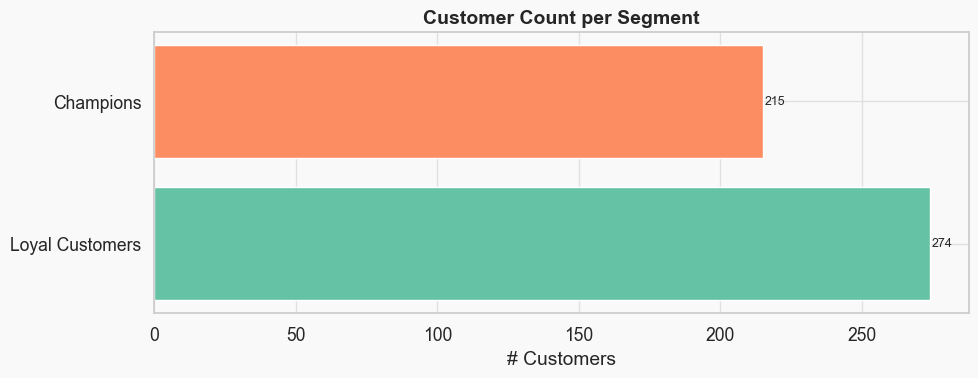

In [27]:
# 4.8  Segment size bar chart
seg_count = rfm["Segment"].value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(seg_count.index, seg_count.values,
               color=PALETTE[:len(seg_count)], edgecolor="white")
ax.set_title("Customer Count per Segment", fontsize=14, fontweight="bold")
ax.set_xlabel("# Customers")
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())), va="center", fontsize=9)
plt.tight_layout(); plt.show()


---
## Phase 5 · KPI Development
**Owner:** Mohamed HADJI

| KPI | Description |
|-----|-------------|
| **CLV** | Total revenue per customer over the observation period |
| **AOV** | Mean transaction amount |
| **Purchase Frequency** | Avg number of transactions per customer |
| **Avg Basket Size** | Avg quantity of items per transaction |
| **Churn Proxy** | % customers inactive beyond a threshold |
| **Retention Rate** | % customers with 2+ purchases |

In [28]:
# 5.1  Global KPIs
OBS_DAYS          = max((df["date"].max() - df["date"].min()).days, 1)
aov               = df["total"].mean()
total_customers   = df["customer_id"].nunique()
total_txns        = df["transaction_id"].nunique()
freq              = total_txns / total_customers
basket_size       = df["quantity"].mean() if "quantity" in df.columns else None
clv_global        = rfm["Monetary"].mean()

CHURN_DAYS  = 90
churn_rate  = (rfm["Recency"] > CHURN_DAYS).mean() * 100
ret_rate    = (rfm["Frequency"] >= 2).mean() * 100

line = "=" * 54
print(line)
print("  GLOBAL CRM KPI DASHBOARD")
print(line)
print(f"  Observation period  : {OBS_DAYS} days")
print(f"  Unique customers    : {total_customers:,}")
print(f"  Unique transactions : {total_txns:,}")
print(f"  Avg Order Value     : ${aov:,.2f}")
print(f"  Purchase Frequency  : {freq:.2f} txns/customer")
if basket_size is not None:
    print(f"  Avg Basket Size     : {basket_size:.2f} units/txn")
print(f"  Customer LTV (avg)  : ${clv_global:,.2f}")
print(f"  Churn Proxy (>{CHURN_DAYS}d)  : {churn_rate:.1f}%")
print(f"  Retention Rate      : {ret_rate:.1f}%")
print(line)


  GLOBAL CRM KPI DASHBOARD
  Observation period  : 364 days
  Unique customers    : 489
  Unique transactions : 2,000
  Avg Order Value     : $1,234.19
  Purchase Frequency  : 4.09 txns/customer
  Avg Basket Size     : 4.99 units/txn
  Customer LTV (avg)  : $5,047.83
  Churn Proxy (>90d)  : 38.0%
  Retention Rate      : 90.6%


In [29]:
# 5.2  KPIs per segment
df_seg = df.merge(rfm[["customer_id", "Segment", "Recency", "Frequency"]],
                  on="customer_id", how="left")

seg_kpi = df_seg.groupby("Segment").agg(
    Customers     = ("customer_id",    "nunique"),
    Transactions  = ("transaction_id", "nunique"),
    Total_Revenue = ("total",          "sum"),
    AOV           = ("total",          "mean"),
).round(2)

seg_kpi["Avg_Frequency"] = (seg_kpi["Transactions"] / seg_kpi["Customers"]).round(2)
seg_kpi["CLV_avg"]       = (seg_kpi["Total_Revenue"] / seg_kpi["Customers"]).round(2)

churn_s = rfm[rfm["Recency"] > CHURN_DAYS].groupby("Segment").size().rename("Churned")
repeat_s = rfm[rfm["Frequency"] >= 2].groupby("Segment").size().rename("Repeat")

seg_kpi = seg_kpi.join(churn_s, how="left").fillna(0)
seg_kpi = seg_kpi.join(repeat_s, how="left").fillna(0)
seg_kpi["Churn_Rate_pct"]  = (seg_kpi["Churned"] / seg_kpi["Customers"] * 100).round(1)
seg_kpi["Retention_pct"]   = (seg_kpi["Repeat"]  / seg_kpi["Customers"] * 100).round(1)

display(seg_kpi.sort_values("Total_Revenue", ascending=False))


,Customers,Transactions,Total_Revenue,AOV,Avg_Frequency,CLV_avg,Churned,Repeat,Churn_Rate_pct,Retention_pct
Segment,,,,,,,,,,
Champions,215,1279,1693425.82,1324.02,5.95,7876.40,26,215,12.1,100.0
Loyal Customers,274,721,774962.17,1074.84,2.63,2828.33,160,228,58.4,83.2


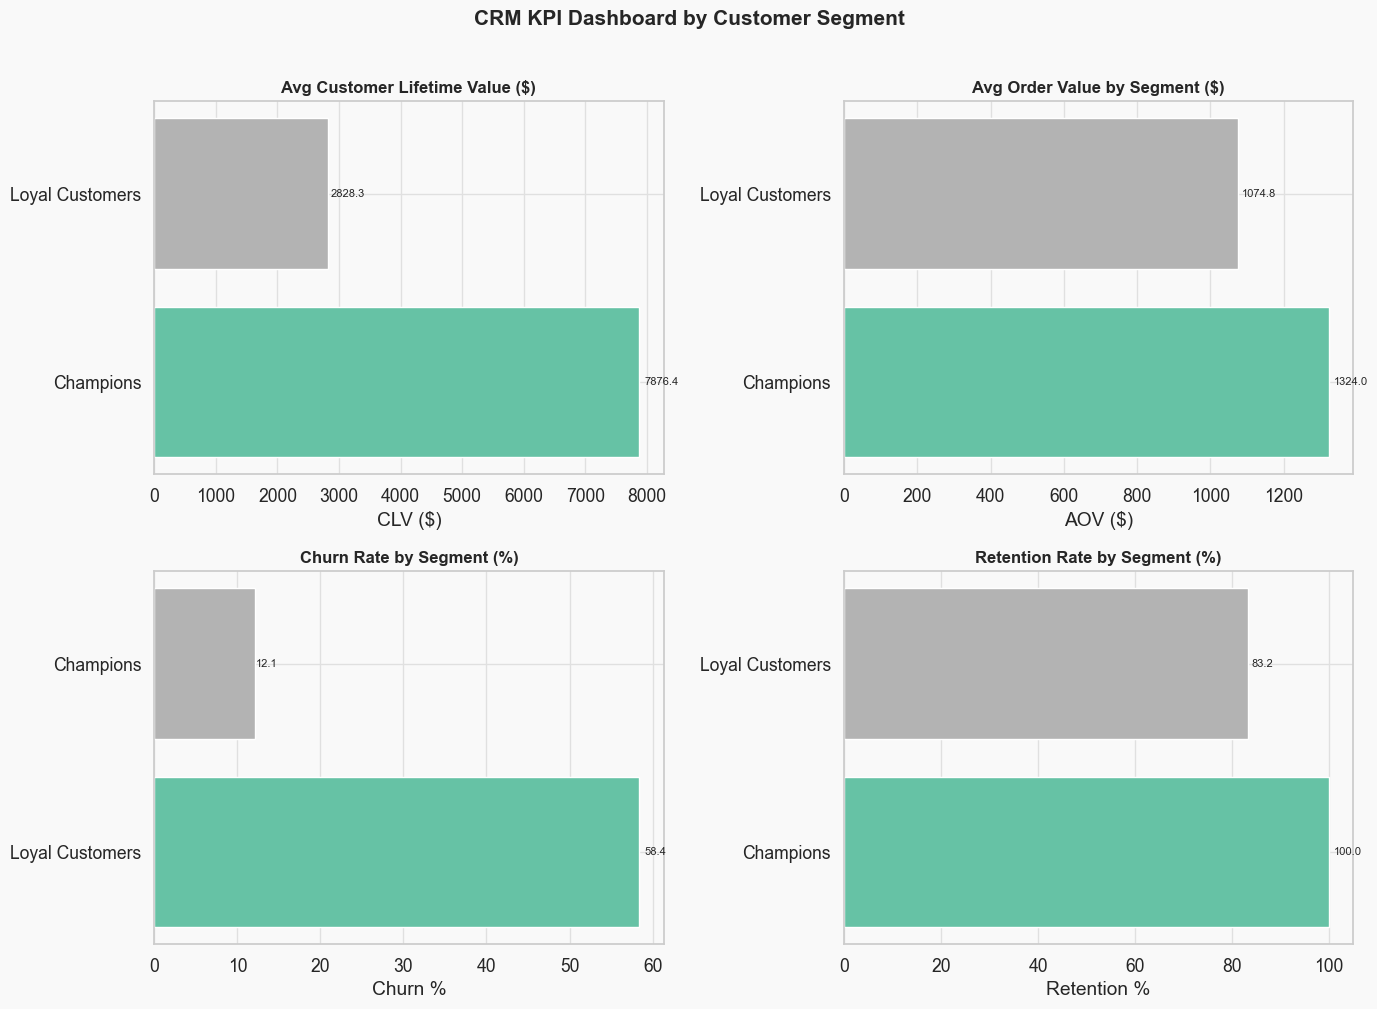

In [30]:
# 5.3  KPI dashboard charts (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
cmap = plt.colormaps["Set2"].resampled(len(seg_kpi))

panels = [
    ("CLV_avg",         "Avg Customer Lifetime Value ($)", "CLV ($)"),
    ("AOV",             "Avg Order Value by Segment ($)",  "AOV ($)"),
    ("Churn_Rate_pct",  "Churn Rate by Segment (%)",       "Churn %"),
    ("Retention_pct",   "Retention Rate by Segment (%)",   "Retention %"),
]
for ax, (metric, title, xlabel) in zip(axes, panels):
    data = seg_kpi[metric].sort_values(ascending=False)
    bars = ax.barh(data.index, data.values,
                   color=[cmap(i) for i in range(len(data))], edgecolor="white")
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.set_xlabel(xlabel)
    for bar in bars:
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width():.1f}", va="center", fontsize=8)

plt.suptitle("CRM KPI Dashboard by Customer Segment",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


---
## Phase 6 · CRM Recommendations & Action Plan
**Owner:** Hiba RHARS

Each segment is mapped to a tailored CRM strategy aligned with
**Activity-based Customer Lifecycle Management (ACLM)**.

In [31]:
# 6.1  CRM Action Matrix definition
CRM_ACTIONS = {
    "Champions": {
        "stage":    "Active – High Value",
        "strategy": "Reward & Retain",
        "channel":  "Personalised email + Mobile App push",
        "kpi_goal": "Retention >= 90%, upsell rate +15%",
        "tactics":  [
            "VIP loyalty tier: early access to sales & new arrivals",
            "Personalised thank-you emails with points balance update",
            "Referral programme: bonus credits for successful referrals",
            "Co-creation invites: product feedback panels & beta testing",
        ],
    },
    "Loyal Customers": {
        "stage":    "Active – Medium-High Value",
        "strategy": "Increase Frequency & Basket Size",
        "channel":  "Email + SMS",
        "kpi_goal": "AOV +10%, frequency +1 txn/quarter",
        "tactics":  [
            "Cross-sell complementary product categories",
            "Bundle discount: Buy 3 save 10% on top-purchased categories",
            "Double-points weekends to boost purchase cadence",
            "Monthly curated newsletter with personalised top picks",
        ],
    },
    "At-Risk Customers": {
        "stage":    "Declining – Formerly Active",
        "strategy": "Win-Back Campaign",
        "channel":  "Email + Retargeting Ads",
        "kpi_goal": "Recover 20% of at-risk revenue within 60 days",
        "tactics":  [
            "Re-engagement email: 'We miss you' with 15% discount code",
            "Personalised product recommendations based on past purchases",
            "Limited-time offer (7-day countdown) to create urgency",
            "Short survey: understand reasons for disengagement",
        ],
    },
    "Lost Customers": {
        "stage":    "Churned",
        "strategy": "Reactivation or GDPR-compliant suppression",
        "channel":  "Email (single final campaign)",
        "kpi_goal": "5–10% reactivation rate",
        "tactics":  [
            "Last-chance offer: one-time 20% discount",
            "If no response: suppress from further campaigns (GDPR Art. 7)",
            "Post-mortem analysis: price? experience? competitor?",
        ],
    },
    "New Customers": {
        "stage":    "Onboarding",
        "strategy": "Engage & Convert to Loyals",
        "channel":  "Email sequence + In-app notifications",
        "kpi_goal": "30% convert to repeat buyers within 90 days",
        "tactics":  [
            "3-email welcome series: brand story, best sellers, loyalty intro",
            "Post-first-purchase survey + cross-sell suggestion",
            "Sign-up bonus points to incentivise second purchase",
            "Product usage tips and how-to content",
        ],
    },
    "Potential Loyalists": {
        "stage":    "Growing",
        "strategy": "Nurture toward Champions tier",
        "channel":  "Email + Mobile App",
        "kpi_goal": "Frequency +2 txns over next 6 months",
        "tactics":  [
            "Targeted promotions on highest-affinity product category",
            "Progress bar: 'X points away from VIP status'",
            "Exclusive flash sales on slow sales days",
        ],
    },
}
print("CRM Action Matrix loaded –", len(CRM_ACTIONS), "segments defined.")


CRM Action Matrix loaded – 6 segments defined.


In [32]:
# 6.2  Tabular summary of CRM actions
rows = []
for seg, info in CRM_ACTIONS.items():
    rows.append({
        "Segment":        seg,
        "Lifecycle Stage": info["stage"],
        "Strategy":       info["strategy"],
        "Channel":        info["channel"],
        "KPI Goal":       info["kpi_goal"],
        "# Tactics":      len(info["tactics"]),
    })
action_df = pd.DataFrame(rows)
display(action_df)


,Segment,Lifecycle Stage,Strategy,Channel,KPI Goal,# Tactics
0,Champions,Active – High Value,Reward & Retain,Personalised email + Mobile App push,"Retention >= 90%, upsell rate +15%",4
1,Loyal Customers,Active – Medium-High Value,Increase Frequency & Basket Size,Email + SMS,"AOV +10%, frequency +1 txn/quarter",4
2,At-Risk Customers,Declining – Formerly Active,Win-Back Campaign,Email + Retargeting Ads,Recover 20% of at-risk revenue within 60 days,4
3,Lost Customers,Churned,Reactivation or GDPR-compliant suppression,Email (single final campaign),5–10% reactivation rate,3
4,New Customers,Onboarding,Engage & Convert to Loyals,Email sequence + In-app notifications,30% convert to repeat buyers within 90 days,4
5,Potential Loyalists,Growing,Nurture toward Champions tier,Email + Mobile App,Frequency +2 txns over next 6 months,3


In [33]:
# 6.3  Detailed tactic printout per detected segment
detected = rfm["Segment"].unique().tolist() if "Segment" in rfm.columns else []
SEP = "=" * 65
for seg, info in CRM_ACTIONS.items():
    if seg in detected:
        n = (rfm["Segment"] == seg).sum()
        pct = n / len(rfm) * 100
        print(SEP)
        print(f"  {seg.upper():50s} ({n:,} customers | {pct:.1f}%)")
        print(f"  Stage    : {info['stage']}")
        print(f"  Strategy : {info['strategy']}")
        print(f"  Channel  : {info['channel']}")
        print(f"  KPI Goal : {info['kpi_goal']}")
        print("  Tactics  :")
        for t in info["tactics"]:
            print(f"    * {t}")
print(SEP)


  CHAMPIONS                                          (215 customers | 44.0%)
  Stage    : Active – High Value
  Strategy : Reward & Retain
  Channel  : Personalised email + Mobile App push
  KPI Goal : Retention >= 90%, upsell rate +15%
  Tactics  :
    * VIP loyalty tier: early access to sales & new arrivals
    * Personalised thank-you emails with points balance update
    * Referral programme: bonus credits for successful referrals
    * Co-creation invites: product feedback panels & beta testing
  LOYAL CUSTOMERS                                    (274 customers | 56.0%)
  Stage    : Active – Medium-High Value
  Strategy : Increase Frequency & Basket Size
  Channel  : Email + SMS
  KPI Goal : AOV +10%, frequency +1 txn/quarter
  Tactics  :
    * Cross-sell complementary product categories
    * Bundle discount: Buy 3 save 10% on top-purchased categories
    * Double-points weekends to boost purchase cadence
    * Monthly curated newsletter with personalised top picks


In [34]:
# 6.4  CRM Priority Bubble Chart: Churn Risk vs CLV
seg_bubble = seg_kpi.reset_index()
# Ensure the index column (Segment) is named correctly
if seg_bubble.columns[0] != "Segment":
    seg_bubble = seg_bubble.rename(columns={seg_bubble.columns[0]: "Segment"})

fig_bub = px.scatter(
    seg_bubble,
    x="Churn_Rate_pct",
    y="CLV_avg",
    size="Customers",
    color="Segment",
    text="Segment",
    title="CRM Priority Matrix: Churn Risk vs Customer Lifetime Value",
    labels={"Churn_Rate_pct": "Churn Rate (%)", "CLV_avg": "Avg CLV ($)"},
    size_max=60,
    height=520,
)
fig_bub.update_traces(textposition="top center", textfont_size=10)
fig_bub.add_annotation(
    x=0.01, y=0.98, xref="paper", yref="paper",
    text="^ High CLV, Low Churn = PROTECT | > Low CLV, High Churn = DECIDE",
    showarrow=False, align="left",
    bordercolor="#888", borderwidth=1,
    bgcolor="white", font=dict(size=10),
)
fig_bub.show()


---
## Executive Summary

| Phase | Deliverable |
|-------|-------------|
| **Data Cleaning** | Clean, typed, duplicate-free transaction dataset |
| **GDPR Review** | Risk-tagged fields; anonymisation strategy documented |
| **EDA** | Revenue trends, category/city/payment/demographics insights |
| **RFM + K-Means** | Data-driven customer segments with business labels |
| **KPI Dashboard** | CLV, AOV, Frequency, Churn %, Retention % per segment |
| **CRM Actions** | Segment-specific strategies aligned with ACLM |

### Key Takeaways
- **Champions** and **Loyal Customers** are the revenue engine — prioritise retention investments.
- **At-Risk** and **Lost** clusters require time-sensitive win-back campaigns.
- **New Customers** need a structured onboarding journey to build loyalty.
- Combining quintile RFM scores with K-Means yields richer segments than quintiles alone.

### GDPR Reminder
Customer IDs are opaque tokens throughout. City data is used only for aggregates.
Under Art. 89 GDPR, academic research using publicly available data is permissible
with appropriate technical and organisational safeguards.

---
*IS513E – Database for Direct Marketing & E-CRM |
Group: Chaker · Hadji · Rhars · Sawant | February 2026*